In [62]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
paradigm = P300(tmin=-1, tmax=2, resample=None, fmin=0.1, fmax=None)
dataset = BNCI2014008()

In [64]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.


<RawArray | 10 x 347704 (1358.2 s), ~26.5 MB, data loaded>

In [65]:
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-1.000 – 2.000 sec
Baseline,off


In [72]:
n_freqs = 20
freqs = np.linspace(1,20,n_freqs)
n_cycles = 0.8*freqs
sfreq=64

epochs_tfr = tfr_morlet(
    epochs, freqs, n_cycles, return_itc=False, average=False,
    output='power', verbose=True, n_jobs=-1,
                        decim=int(epochs.info['sfreq']//sfreq))
epochs_tfr.apply_baseline((-0.2,1.0), mode='logratio')
epochs_tfr.crop(-0.2, 1.0)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   8 | elapsed:   13.3s remaining:   22.2s
[Parallel(n_jobs=-1)]: Done   5 out of   8 | elapsed:   14.3s remaining:    8.6s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:   15.8s finished


Not setting metadata
Applying baseline correction (mode: logratio)


<EpochsTFR | time : [-0.203125, 1.000000], freq : [1.000000, 20.000000], epochs : 4200, channels : 8, ~399.9 MB>

No baseline correction applied


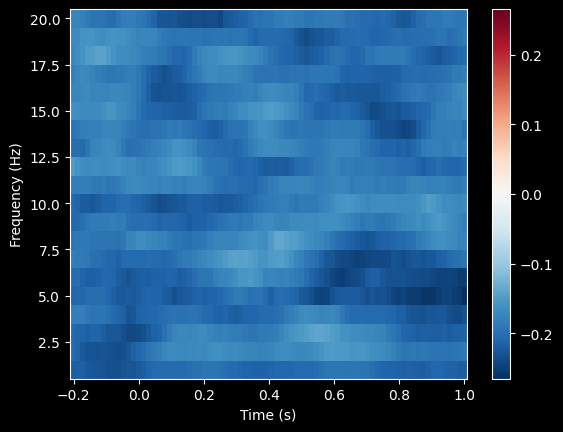

No baseline correction applied


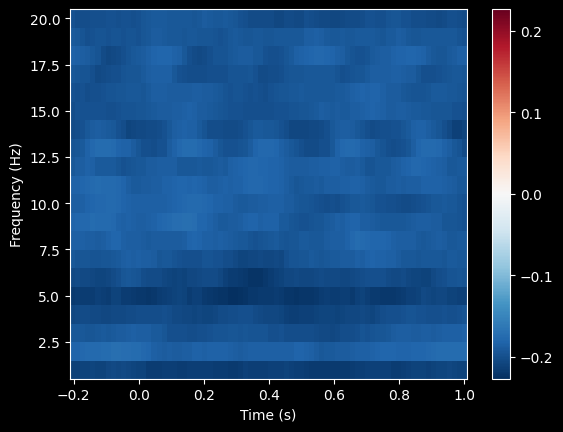

No baseline correction applied


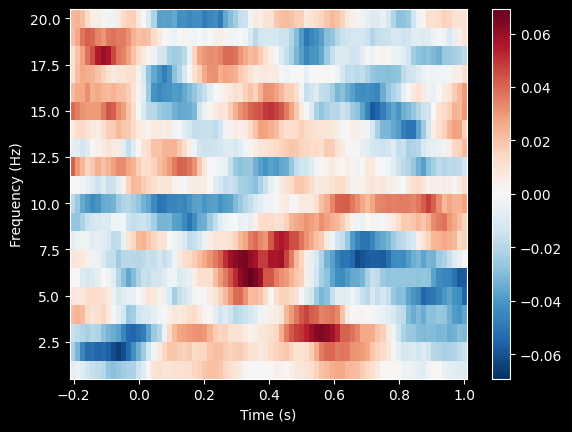

In [73]:
from mne import combine_evoked

plt.style.use('dark_background')


target = epochs_tfr['Target'].average()
non_target = epochs_tfr['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])

vmax = np.max(np.abs(target.data))
tfr_args=dict(picks=['Cz'])

_ = target.plot(**tfr_args)
_ = non_target.plot(**tfr_args)
_ = contrast.plot(**tfr_args)


In [74]:
import tensorly as tl
tl.set_backend('numpy')

X = tl.tensor(epochs_tfr.data)
y = labels

In [ ]:
import cupy
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

hoda = HODA(
            rank=None,
            max_iter=32,
            tol=1e-4,
            init ='mlsvd',
            verbose=True,
            shrinkage=('lw', 'lw', 'lw'),
            toeplitz=(2,),
            taper=False,
            solver='lfl',
            keep_train_info=True,
)
hoda.fit(X,y)

Initializing factors...
Fitting discriminative tucker model of rank [2, 5, 19] ...


  0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
fig, axs = plt.subplots(5,1, sharex=True, figsize=(6,10))

axs[0].set_title('Fisher score')
axs[0].plot(hoda.train_info_["f_score"])

axs[1].set_title('Objective')
axs[1].semilogy(np.asarray(hoda.train_info_["mode_objective"]).T, label=['Mode 0', 'Mode 1', 'Mode 3'])
axs[1].legend()

axs[2].set_title('MSE')
axs[2].semilogy(hoda.train_info_["mse"])

axs[3].set_title('Update')
axs[3].semilogy(np.asarray(hoda.train_info_["mode_update"]).T, label=['Mode 0', 'Mode 1', 'Mode 3'])
axs[3].legend()

axs[4].set_title('Shrinkage')
axs[4].plot(np.asarray(hoda.train_info_["mode_shrinkage"]).T, label=['Mode 0', 'Mode 1', 'Mode 3'])
axs[4].legend()

In [ ]:
fig, axs = plt.subplots(2,3, layout='tight', figsize=(12,6))
for k in range(3):
    scatter_b = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    sns.heatmap(scatter_b, ax=axs[0,k], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axs[0,k].set_aspect('equal')
    scatter_w = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(scatter_w)
    sns.heatmap(scatter_w, ax=axs[1,k], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axs[1,k].set_aspect('equal')

In [ ]:
fig, axs = plt.subplots(1,max(hoda.rank_[0],2), figsize=(16,6), layout='tight')
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False, cmap='magma')

fig, axs = plt.subplots(1,max(hoda.rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.scalings_[1][:,i])
    axs[i].plot(freqs, w)
    axs[i].set_xlabel('Frequency band')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');

fig, axs = plt.subplots(1,max(hoda.rank_[2],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[2]):
    w = cupy.asnumpy(hoda.scalings_[2][:,i])
    axs[i].plot(epochs_tfr.times, np.abs(w))
    axs[i].set_xlabel('Time (s)')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');

In [ ]:
fig, axs = plt.subplots(1,max(hoda.rank_[0],2), figsize=(16,6), layout='tight')
A = hoda.scatter_w_[0] @ hoda.scalings_[0] @ hoda.cov_l_inv_[0]
for i in range(hoda.rank_[0]):
    plot_topomap(cupy.asnumpy(A[:,i]), epochs.info, axes=axs[i], show=False)

A = hoda.scatter_w_[1] @ hoda.scalings_[1] @ hoda.cov_l_inv_[1]
fig, axs = plt.subplots(1,max(hoda.rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    axs[i].plot(freqs, cupy.asnumpy(A[:,i]))
    axs[i].set_xlabel('Frequency band')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');

A = hoda.scatter_w_[2] @ hoda.scalings_[2] @ hoda.cov_l_inv_[2]
fig, axs = plt.subplots(1,max(hoda.rank_[2],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[2]):
    axs[i].plot(epochs_tfr.times,cupy.asnumpy(A[:,i]))
    axs[i].set_xlabel('Time (s)')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');